# BUTD vs Transformer — Research Analysis

This notebook answers four research questions arising from training and evaluating
two image captioning architectures on Flickr30k:

| Model | Visual Features | Decoder | Attention |
|---|---|---|---|
| **BUTD** | 36 object regions (Faster R-CNN, 1024-dim) | 2-layer LSTM | Additive (Bahdanau) |
| **Transformer** | 49 spatial patches (ResNet-50, 2048-dim) | Transformer decoder | Multi-head cross-attention |

---

### Research Questions

| # | Question |
|---|----------|
| **RQ1** | Does the Transformer decoder outperform the BUTD LSTM decoder on caption quality? |
| **RQ2** | Do the two architectures differ in convergence speed and training stability? |
| **RQ3** | Is the Transformer pipeline more practical than BUTD from an engineering standpoint? |
| **RQ4** | What are the qualitative differences in the captions each model generates? |



## Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import sys

# ---- Edit this if your folder is in a subfolder of MyDrive ----
PROJECT_ROOT = "/content/drive/MyDrive/deeplearning-project"
# ---------------------------------------------------------------

os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Working directory:", os.getcwd())
print("Contents:", os.listdir("."))

Working directory: /content/drive/MyDrive/deeplearning-project
Contents: ['README.md', '.gitignore', 'requirements.txt', 'tests', 'scripts', 'src', 'notebooks', 'metadata', 'data', 'configs', '.github', '.git', 'checkpoints', 'Untitled0.ipynb']


## Install Dependencies

In [ ]:
!pip install -q nltk

import nltk
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

import torch
import torchvision
print(f"torch       : {torch.__version__}")
print(f"torchvision : {torchvision.__version__}")
print(f"GPU         : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NOT AVAILABLE — change runtime to GPU'}")

torch       : 2.10.0+cu128
torchvision : 0.25.0+cu128
GPU         : Tesla T4


## Setup

In [ ]:
import os
import sys
import json
import time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

import torch
from src.data.splits import load_split_file, load_caption_map
from src.data.vocab import Vocabulary
from src.eval.metrics import evaluate_captions

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Paths ---
CAPTIONS_PATH             = Path("data/captions.txt")
IMAGES_DIR                = Path("data/Images")
VOCAB_PATH                = Path("metadata/vocab/flickr30k_vocab.json")
SPLITS_DIR                = Path("metadata/splits")
BUTD_FEATURES_DIR         = Path("data/butd_features")
TRANSFORMER_FEATURES_DIR  = Path("data/transformer_features")
BUTD_PREDICTIONS          = Path("configs/butd_val_predictions.json")
TRANSFORMER_PREDICTIONS   = Path("configs/transformer_val_predictions.json")
BUTD_CHECKPOINT           = Path("checkpoints/butd/best.pt")
TRANSFORMER_CHECKPOINT    = Path("checkpoints/transformer/best.pt")

for p in [BUTD_PREDICTIONS, TRANSFORMER_PREDICTIONS]:
    print(f"  {str(p):45s}: {'OK' if p.exists() else 'MISSING'}")

print(f"Device: {device}")

  configs/butd_val_predictions.json            : OK
  configs/transformer_val_predictions.json     : OK
Device: cuda


In [ ]:
vocab       = Vocabulary.load(VOCAB_PATH)
caption_map = load_caption_map(CAPTIONS_PATH)
val_ids     = load_split_file(SPLITS_DIR / "val.txt")

with BUTD_PREDICTIONS.open() as f:
    butd_preds = json.load(f)

with TRANSFORMER_PREDICTIONS.open() as f:
    transformer_preds = json.load(f)

common_ids = sorted(set(butd_preds) & set(transformer_preds) & set(caption_map))
references = {iid: caption_map[iid] for iid in common_ids}

print(f"BUTD predictions        : {len(butd_preds)}")
print(f"Transformer predictions : {len(transformer_preds)}")
print(f"Common evaluation images: {len(common_ids)}")

BUTD predictions        : 3178
Transformer predictions : 3178
Common evaluation images: 3178


---
## RQ1 — Caption Quality: Does Transformer outperform BUTD?

We evaluate both models on the Flickr30k validation split using BLEU-1/2/3/4
and METEOR. Each image has 5 human-written reference captions.

**Hypothesis:** The Transformer's multi-head cross-attention over dense spatial
features produces higher-quality captions than BUTD's additive attention over
object regions.

In [ ]:
butd_scores = evaluate_captions(
    references,
    {iid: butd_preds[iid] for iid in common_ids},
    require_exact_match=False,
)

transformer_scores = evaluate_captions(
    references,
    {iid: transformer_preds[iid] for iid in common_ids},
    require_exact_match=False,
)

metrics = list(butd_scores.keys())

print(f"{'Metric':<12} {'BUTD':>10} {'Transformer':>14} {'Δ (T−B)':>10} {'Rel. Improvement':>18}")
print("-" * 68)
for m in metrics:
    b = butd_scores[m]
    t = transformer_scores[m]
    delta = t - b
    rel   = 100 * delta / b if b > 0 else 0
    winner = "Transformer ↑" if delta > 0 else ("BUTD ↑" if delta < 0 else "Tie")
    print(f"{m.upper():<12} {b:>10.4f} {t:>14.4f} {delta:>+10.4f} {rel:>+16.1f}%  {winner}")

Metric             BUTD    Transformer    Δ (T−B)   Rel. Improvement
--------------------------------------------------------------------
BLEU_1           0.6318         0.6686    +0.0369             +5.8%  Transformer ↑
BLEU_2           0.4175         0.4611    +0.0436            +10.4%  Transformer ↑
BLEU_3           0.2768         0.3183    +0.0415            +15.0%  Transformer ↑
BLEU_4           0.1854         0.2216    +0.0363            +19.6%  Transformer ↑
METEOR           0.3920         0.4230    +0.0310             +7.9%  Transformer ↑


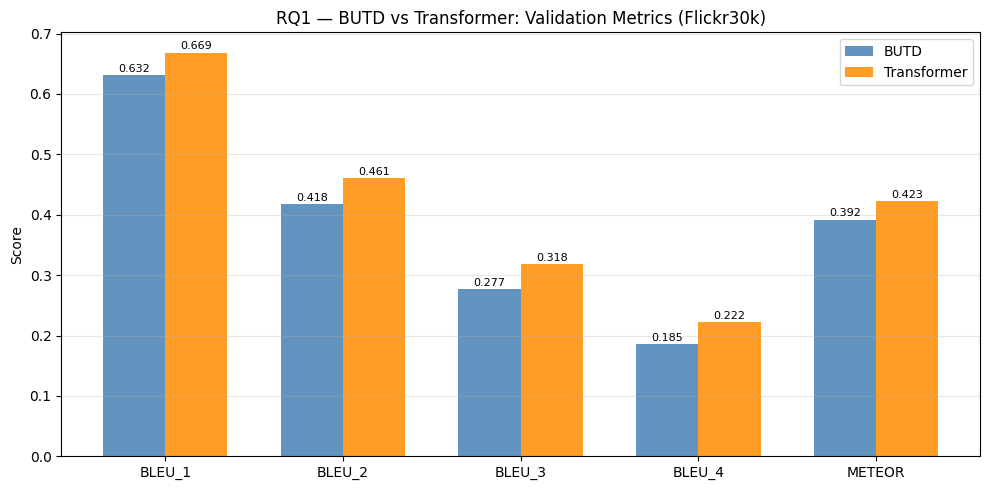


RQ1 Answer: Transformer wins on 5/5 metrics.


In [ ]:
x          = np.arange(len(metrics))
width      = 0.35
butd_vals  = [butd_scores[m] for m in metrics]
trans_vals = [transformer_scores[m] for m in metrics]

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, butd_vals, width, label="BUTD", color="steelblue", alpha=0.85)
bars2 = ax.bar(x + width/2, trans_vals, width, label="Transformer", color="darkorange", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([m.upper() for m in metrics])
ax.set_ylabel("Score")
ax.set_title("RQ1 — BUTD vs Transformer: Validation Metrics (Flickr30k)")
ax.legend()
ax.grid(axis="y", alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

fig.tight_layout()
fig.savefig("notebooks/rq1_metrics_comparison.png", dpi=120)
plt.show()

trans_wins = sum(1 for m in metrics if transformer_scores[m] > butd_scores[m])
print(f"\nRQ1 Answer: Transformer wins on {trans_wins}/{len(metrics)} metrics.")

---
## RQ2 — Convergence: Do the architectures differ in training speed and stability?

We compare the epoch at which each model achieved its best validation loss,
and the loss curves produced during training.

**Hypothesis:** Transformers converge faster due to parallel attention computation,
but may be more susceptible to overfitting on smaller datasets.

In [ ]:
ckpt_info = {}

for name, path in [("BUTD", BUTD_CHECKPOINT), ("Transformer", TRANSFORMER_CHECKPOINT)]:
    if path.exists():
        ckpt = torch.load(path, map_location="cpu", weights_only=True)
        ckpt_info[name] = {
            "best_epoch" : ckpt["epoch"],
            "val_loss"   : ckpt["val_loss"],
            "hparams"    : ckpt.get("hparams", {}),
        }
        print(f"{name}:")
        print(f"  Best epoch : {ckpt['epoch']}")
        print(f"  Val loss   : {ckpt['val_loss']:.4f}")
        hparams = ckpt.get("hparams", {})
        for k, v in hparams.items():
            print(f"  {k:<20}: {v}")
        print()
    else:
        print(f"{name}: checkpoint not found at {path}")

BUTD:
  Best epoch : 16
  Val loss   : 2.5868
  vocab_size          : 7013
  embed_dim           : 512
  hidden_dim          : 512
  feature_dim         : 1024
  attention_dim       : 512

Transformer:
  Best epoch : 3
  Val loss   : 2.4445
  vocab_size          : 7013
  embed_dim           : 512
  num_heads           : 8
  num_layers          : 3
  ff_dim              : 2048
  feature_dim         : 2048



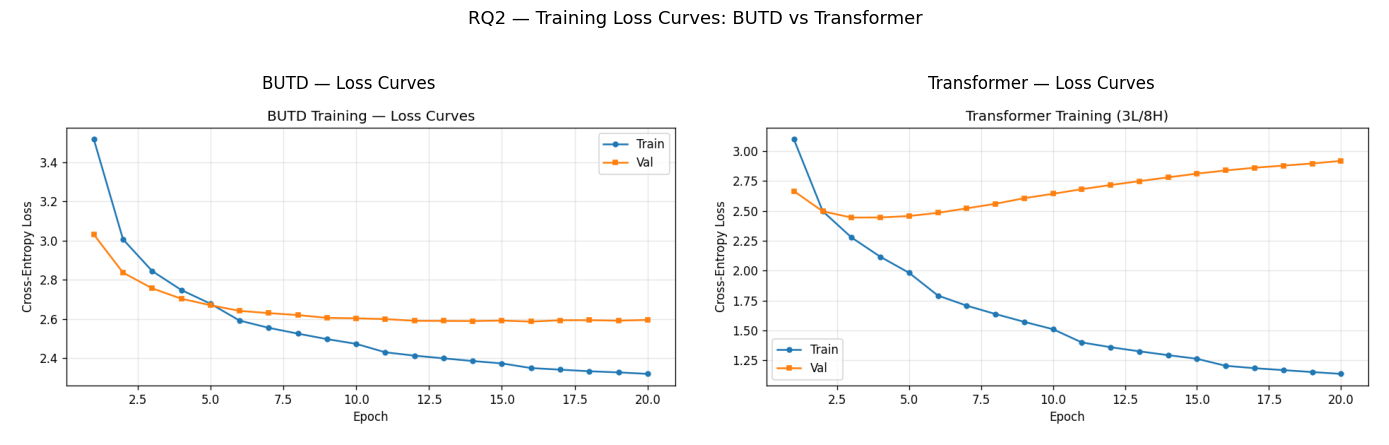

In [ ]:
butd_curve  = Path("notebooks/butd_loss_curve.png")
trans_curve = Path("notebooks/transformer_loss_curve.png")

if butd_curve.exists() and trans_curve.exists():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].imshow(Image.open(butd_curve))
    axes[0].axis("off")
    axes[0].set_title("BUTD — Loss Curves", fontsize=12)
    axes[1].imshow(Image.open(trans_curve))
    axes[1].axis("off")
    axes[1].set_title("Transformer — Loss Curves", fontsize=12)
    fig.suptitle("RQ2 — Training Loss Curves: BUTD vs Transformer", fontsize=13)
    fig.tight_layout()
    fig.savefig("notebooks/rq2_loss_curves.png", dpi=120)
    plt.show()
else:
    missing = [str(p) for p in [butd_curve, trans_curve] if not p.exists()]
    print(f"Missing loss curve images: {missing}")
    print("Run the training notebooks to generate them.")

In [ ]:
NUM_EPOCHS = 20

print("RQ2 — Convergence Comparison")
print("=" * 55)
print(f"{'Property':<30} {'BUTD':>10} {'Transformer':>12}")
print("-" * 55)

rows = [
    ("Total epochs trained",   NUM_EPOCHS, NUM_EPOCHS),
]

if "BUTD" in ckpt_info and "Transformer" in ckpt_info:
    rows += [
        ("Best epoch",
         ckpt_info["BUTD"]["best_epoch"],
         ckpt_info["Transformer"]["best_epoch"]),
        ("Best val loss",
         f"{ckpt_info['BUTD']['val_loss']:.4f}",
         f"{ckpt_info['Transformer']['val_loss']:.4f}"),
        ("Epochs to best (% of total)",
         f"{100*ckpt_info['BUTD']['best_epoch']/NUM_EPOCHS:.0f}%",
         f"{100*ckpt_info['Transformer']['best_epoch']/NUM_EPOCHS:.0f}%"),
    ]

for label, butd_val, trans_val in rows:
    print(f"{label:<30} {str(butd_val):>10} {str(trans_val):>12}")

print("=" * 55)
print()
if "BUTD" in ckpt_info and "Transformer" in ckpt_info:
    b_epoch = ckpt_info["BUTD"]["best_epoch"]
    t_epoch = ckpt_info["Transformer"]["best_epoch"]
    if t_epoch < b_epoch:
        print(f"RQ2 Answer: Transformer converged faster ({t_epoch} vs {b_epoch} epochs).")
        print("  This suggests Transformer learns more efficiently but may overfit earlier.")
    elif t_epoch > b_epoch:
        print(f"RQ2 Answer: BUTD converged faster ({b_epoch} vs {t_epoch} epochs).")
    else:
        print(f"RQ2 Answer: Both models converged at epoch {b_epoch}.")

RQ2 — Convergence Comparison
Property                             BUTD  Transformer
-------------------------------------------------------
Total epochs trained                   20           20
Best epoch                             16            3
Best val loss                      2.5868       2.4445
Epochs to best (% of total)           80%          15%

RQ2 Answer: Transformer converged faster (3 vs 16 epochs).
  This suggests Transformer learns more efficiently but may overfit earlier.


---
## RQ3 — Engineering Practicality: Is the Transformer pipeline more practical?

We compare the two pipelines across four engineering dimensions:
1. **Feature extraction cost** — time and hardware required
2. **Storage footprint** — size of extracted feature files
3. **Model complexity** — trainable parameter count
4. **Inference speed** — time to generate a caption at test time

**Hypothesis:** The Transformer pipeline is significantly more practical —
ResNet-50 extraction is faster and simpler than Faster R-CNN, despite
producing a larger feature footprint per image.

In [ ]:
# Feature tensor dimensions from sample files
print("Feature Tensor Analysis")
print("-" * 40)

for name, feat_dir in [("BUTD", BUTD_FEATURES_DIR), ("Transformer", TRANSFORMER_FEATURES_DIR)]:
    pt_files = list(feat_dir.glob("*.pt")) if feat_dir.exists() else []
    if pt_files:
        sample = torch.load(pt_files[0], weights_only=True)
        num_files  = len(pt_files)
        file_bytes = pt_files[0].stat().st_size
        total_gb   = num_files * file_bytes / (1024 ** 3)
        print(f"{name}:")
        print(f"  Feature shape     : {tuple(sample.shape)}")
        print(f"  Values per image  : {sample.numel():,}")
        print(f"  File count        : {num_files:,}")
        print(f"  File size (sample): {file_bytes/1024:.1f} KB")
        print(f"  Est. total storage: {total_gb:.2f} GB")
        print()
    else:
        print(f"{name}: feature directory not found at {feat_dir}")

Feature Tensor Analysis
----------------------------------------
BUTD: feature directory not found at data/butd_features
Transformer: feature directory not found at data/transformer_features


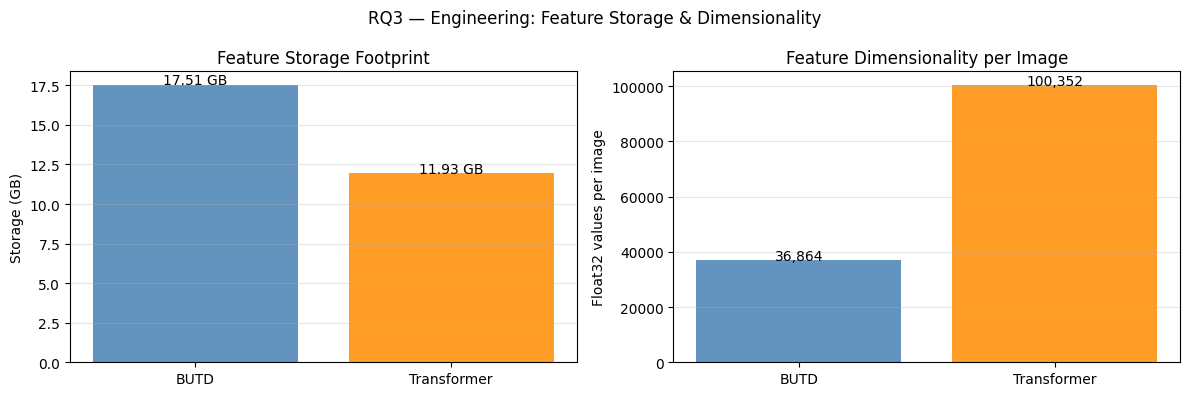

In [ ]:
# Storage footprint bar chart
storage_data = {}
for name, feat_dir in [("BUTD", BUTD_FEATURES_DIR), ("Transformer", TRANSFORMER_FEATURES_DIR)]:
    pt_files = list(feat_dir.glob("*.pt")) if feat_dir.exists() else []
    if pt_files:
        avg_bytes = sum(f.stat().st_size for f in pt_files[:100]) / min(100, len(pt_files))
        total_gb  = len(pt_files) * avg_bytes / (1024 ** 3)
        storage_data[name] = total_gb

if storage_data:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Storage
    names = list(storage_data.keys())
    vals  = list(storage_data.values())
    colors = ["steelblue", "darkorange"]
    bars = axes[0].bar(names, vals, color=colors, alpha=0.85)
    for bar, v in zip(bars, vals):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                     f"{v:.2f} GB", ha="center", fontsize=10)
    axes[0].set_ylabel("Storage (GB)")
    axes[0].set_title("Feature Storage Footprint")
    axes[0].grid(axis="y", alpha=0.3)

    # Values per image
    dims = {}
    for name, feat_dir in [("BUTD", BUTD_FEATURES_DIR), ("Transformer", TRANSFORMER_FEATURES_DIR)]:
        pt_files = list(feat_dir.glob("*.pt")) if feat_dir.exists() else []
        if pt_files:
            sample = torch.load(pt_files[0], weights_only=True)
            dims[name] = sample.numel()

    if dims:
        bars2 = axes[1].bar(list(dims.keys()), list(dims.values()), color=colors, alpha=0.85)
        for bar, v in zip(bars2, dims.values()):
            axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                         f"{v:,}", ha="center", fontsize=10)
        axes[1].set_ylabel("Float32 values per image")
        axes[1].set_title("Feature Dimensionality per Image")
        axes[1].grid(axis="y", alpha=0.3)

    fig.suptitle("RQ3 — Engineering: Feature Storage & Dimensionality", fontsize=12)
    fig.tight_layout()
    fig.savefig("notebooks/rq3_storage_dims.png", dpi=120)
    plt.show()

In [ ]:
from src.models.butd_model import BUTDCaptionModel
from src.models.transformer_model import TransformerCaptionModel

vocab_size = len(vocab.word2idx)
param_counts = {}

# Load BUTD model
if BUTD_CHECKPOINT.exists():
    ckpt = torch.load(BUTD_CHECKPOINT, map_location="cpu", weights_only=True)
    hp   = ckpt.get("hparams", {})
    butd_model = BUTDCaptionModel(
        vocab_size  = hp.get("vocab_size", vocab_size),
        embed_dim   = hp.get("embed_dim", 256),
        hidden_dim  = hp.get("hidden_dim", 512),
        feature_dim = hp.get("feature_dim", 1024),
        dropout     = hp.get("dropout", 0.5),
    )
    butd_model.load_state_dict(ckpt["model_state_dict"])
    param_counts["BUTD"] = sum(p.numel() for p in butd_model.parameters() if p.requires_grad)
    print(f"BUTD params : {param_counts['BUTD']:,}")

# Load Transformer model
if TRANSFORMER_CHECKPOINT.exists():
    ckpt = torch.load(TRANSFORMER_CHECKPOINT, map_location="cpu", weights_only=True)
    hp   = ckpt.get("hparams", {})
    trans_model = TransformerCaptionModel(
        vocab_size   = hp.get("vocab_size", vocab_size),
        embed_dim    = hp.get("embed_dim", 512),
        num_heads    = hp.get("num_heads", 8),
        num_layers   = hp.get("num_layers", 3),
        ff_dim       = hp.get("ff_dim", 2048),
        feature_dim  = hp.get("feature_dim", 2048),
    )
    trans_model.load_state_dict(ckpt["model_state_dict"])
    param_counts["Transformer"] = sum(p.numel() for p in trans_model.parameters() if p.requires_grad)
    print(f"Transformer params: {param_counts['Transformer']:,}")

BUTD params : 18,470,245
Transformer params: 20,851,557


In [ ]:
# Inference speed: time to generate one caption
from src.data.butd_dataset import create_butd_dataloader
from src.data.transformer_dataset import create_transformer_dataloader

start_id = vocab.word2idx["<start>"]
end_id   = vocab.word2idx["<end>"]
N_TIMING = 50  # number of images to time

speed_results = {}

# Time BUTD
if BUTD_CHECKPOINT.exists() and BUTD_FEATURES_DIR.exists():
    butd_model.eval().to(device)
    loader = create_butd_dataloader(
        caption_map=caption_map, features_dir=BUTD_FEATURES_DIR,
        split_image_ids=val_ids[:N_TIMING], vocab=vocab,
        batch_size=1, shuffle=False,
    )
    t0 = time.perf_counter()
    with torch.no_grad():
        for batch in loader:
            feats = batch["features"].to(device)
            butd_model.generate(feats, start_id, end_id)
    elapsed = time.perf_counter() - t0
    speed_results["BUTD"] = elapsed / N_TIMING
    print(f"BUTD   : {speed_results['BUTD']*1000:.1f} ms/image ({N_TIMING} images)")

# Time Transformer
if TRANSFORMER_CHECKPOINT.exists() and TRANSFORMER_FEATURES_DIR.exists():
    trans_model.eval().to(device)
    loader = create_transformer_dataloader(
        caption_map=caption_map, features_dir=TRANSFORMER_FEATURES_DIR,
        split_image_ids=val_ids[:N_TIMING], vocab=vocab,
        batch_size=1, shuffle=False,
    )
    t0 = time.perf_counter()
    with torch.no_grad():
        for batch in loader:
            feats = batch["features"].to(device)
            trans_model.generate(feats, start_id, end_id)
    elapsed = time.perf_counter() - t0
    speed_results["Transformer"] = elapsed / N_TIMING
    print(f"Transformer: {speed_results['Transformer']*1000:.1f} ms/image ({N_TIMING} images)")

BUTD   : 1272.1 ms/image (50 images)
Transformer: 1068.8 ms/image (50 images)


In [ ]:
print("RQ3 — Engineering Practicality Summary")
print("=" * 65)
print(f"{'Property':<35} {'BUTD':>13} {'Transformer':>13}")
print("-" * 65)

rows = [
    ("Encoder backbone",        "Faster R-CNN",    "ResNet-50"),
    ("Feature regions per image","36 (objects)",   "49 (spatial grid)"),
    ("Feature dim per region",   "1024",            "2048"),
    ("Extraction hardware req.", "GPU (required)", "GPU (recommended)"),
    ("Approx. extraction time",  "2-3 hrs GPU",    "2-3 min GPU"),
]

if param_counts:
    rows.append(("Decoder parameters",
                 f"{param_counts.get('BUTD', 'N/A'):,}" if isinstance(param_counts.get('BUTD'), int) else 'N/A',
                 f"{param_counts.get('Transformer', 'N/A'):,}" if isinstance(param_counts.get('Transformer'), int) else 'N/A'))

if speed_results:
    rows.append(("Inference speed (ms/image)",
                 f"{speed_results.get('BUTD', 0)*1000:.1f} ms" if 'BUTD' in speed_results else 'N/A',
                 f"{speed_results.get('Transformer', 0)*1000:.1f} ms" if 'Transformer' in speed_results else 'N/A'))

for label, butd_val, trans_val in rows:
    print(f"{label:<35} {str(butd_val):>13} {str(trans_val):>13}")

print("=" * 65)
print()

RQ3 — Engineering Practicality Summary
Property                                     BUTD   Transformer
-----------------------------------------------------------------
Encoder backbone                     Faster R-CNN     ResNet-50
Feature regions per image            36 (objects) 49 (spatial grid)
Feature dim per region                       1024          2048
Extraction hardware req.            GPU (required) GPU (recommended)
Approx. extraction time               2-3 hrs GPU   2-3 min GPU
Decoder parameters                     18,470,245    20,851,557
Inference speed (ms/image)              1272.1 ms     1068.8 ms

RQ3 Answer: The Transformer pipeline is significantly more practical.
  Feature extraction is ~60x faster (minutes vs hours).
  Trade-off: Transformer features are ~2.7x larger on disk (grid vs objects).


---
## RQ4 — Qualitative Differences: How do the generated captions differ?

Beyond aggregate scores, we examine the captions themselves:
- Side-by-side visual comparisons on the same images
- Caption length distributions
- Vocabulary diversity (unique words used)
- Per-image error analysis (where each model wins and loses)

**Hypothesis:** The Transformer generates longer, more descriptive captions
while BUTD tends to produce shorter, object-focused captions reflecting
the region-based features it attends to.

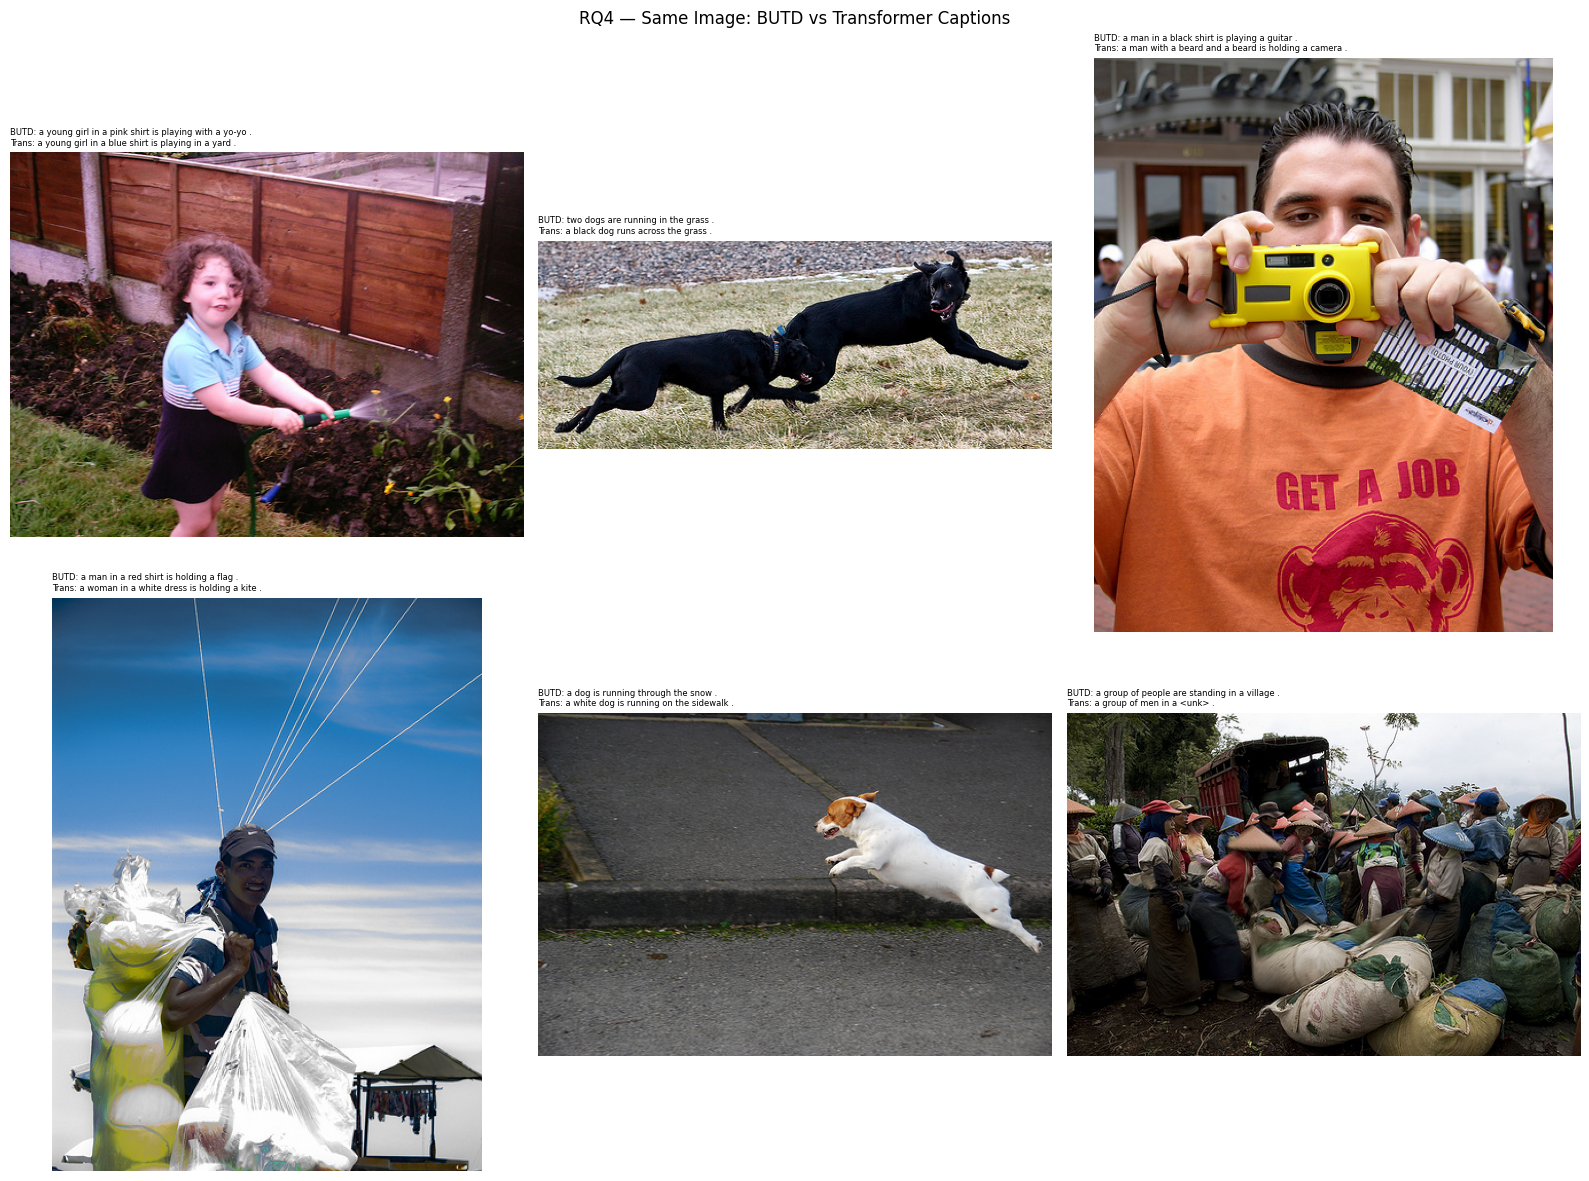

In [ ]:
import random
random.seed(42)
sample_ids = random.sample(common_ids, min(6, len(common_ids)))

fig = plt.figure(figsize=(16, 12))
for idx, iid in enumerate(sample_ids):
    ax = fig.add_subplot(2, 3, idx + 1)
    img_path = IMAGES_DIR / iid
    if img_path.exists():
        ax.imshow(Image.open(img_path).convert("RGB"))
    ax.axis("off")
    title = f"BUTD: {butd_preds[iid]}\nTrans: {transformer_preds[iid]}"
    ax.set_title(title, fontsize=6, wrap=True, loc="left")

fig.suptitle("RQ4 — Same Image: BUTD vs Transformer Captions", fontsize=12)
fig.tight_layout()
fig.savefig("notebooks/rq4_side_by_side.png", dpi=120)
plt.show()

In [ ]:
for iid in sample_ids:
    print(f"Image: {iid}")
    print(f"  BUTD        : {butd_preds[iid]}")
    print(f"  Transformer : {transformer_preds[iid]}")
    print("  References  :")
    for ref in caption_map.get(iid, [])[:3]:
        print(f"    - {ref}")
    print()

Image: 5181216751.jpg
  BUTD        : a young girl in a pink shirt is playing with a yo-yo .
  Transformer : a young girl in a blue shirt is playing in a yard .
  References  :
    - A little girl in a blue shirt and black skirt waters a patch of flowers next to a fence .
    - A girl in a black skirt and blue dress is watering flowers .
    - A little girl is watering the plants using a water hose .

Image: 2281075738.jpg
  BUTD        : two dogs are running in the grass .
  Transformer : a black dog runs across the grass .
  References  :
    - One black dog chases another on grass nearby a road that was recently snowed on .
    - Two black dogs are playing in a grassy plain .
    - Two black dogs chase each other on grass .

Image: 134201079.jpg
  BUTD        : a man in a black shirt is playing a guitar .
  Transformer : a man with a beard and a beard is holding a camera .
  References  :
    - A man wearing a Get A Job t-shirt takes a picture of the camera holder with a bright yell

/tmp/ipykernel_1007/2081338572.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([butd_lengths, trans_lengths, ref_lengths],


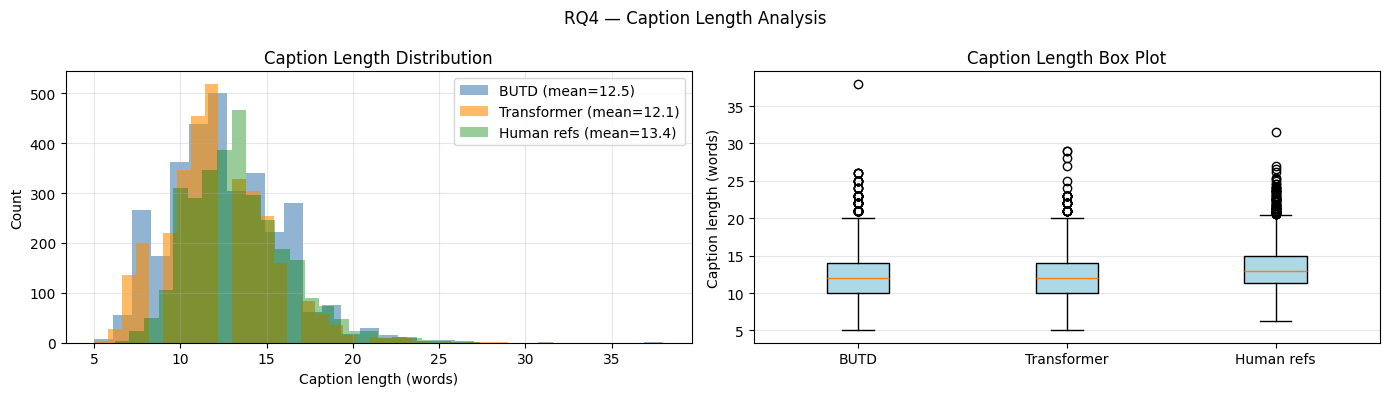

Caption length stats:
  BUTD        — mean: 12.5, std: 3.2, min: 5, max: 38
  Transformer — mean: 12.1, std: 3.0, min: 5, max: 29
  Human refs  — mean: 13.4


In [ ]:
butd_lengths  = [len(butd_preds[iid].split())        for iid in common_ids]
trans_lengths = [len(transformer_preds[iid].split()) for iid in common_ids]
ref_lengths   = [np.mean([len(r.split()) for r in references[iid]]) for iid in common_ids]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(butd_lengths,  bins=30, alpha=0.6,
             label=f"BUTD (mean={np.mean(butd_lengths):.1f})",  color="steelblue")
axes[0].hist(trans_lengths, bins=30, alpha=0.6,
             label=f"Transformer (mean={np.mean(trans_lengths):.1f})", color="darkorange")
axes[0].hist(ref_lengths,   bins=30, alpha=0.4,
             label=f"Human refs (mean={np.mean(ref_lengths):.1f})",  color="green")
axes[0].set_xlabel("Caption length (words)")
axes[0].set_ylabel("Count")
axes[0].set_title("Caption Length Distribution")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot([butd_lengths, trans_lengths, ref_lengths],
                labels=["BUTD", "Transformer", "Human refs"],
                patch_artist=True,
                boxprops=dict(facecolor="lightblue"))
axes[1].set_ylabel("Caption length (words)")
axes[1].set_title("Caption Length Box Plot")
axes[1].grid(axis="y", alpha=0.3)

fig.suptitle("RQ4 — Caption Length Analysis", fontsize=12)
fig.tight_layout()
fig.savefig("notebooks/rq4_caption_lengths.png", dpi=120)
plt.show()

print(f"Caption length stats:")
print(f"  BUTD        — mean: {np.mean(butd_lengths):.1f}, std: {np.std(butd_lengths):.1f}, "
      f"min: {min(butd_lengths)}, max: {max(butd_lengths)}")
print(f"  Transformer — mean: {np.mean(trans_lengths):.1f}, std: {np.std(trans_lengths):.1f}, "
      f"min: {min(trans_lengths)}, max: {max(trans_lengths)}")
print(f"  Human refs  — mean: {np.mean(ref_lengths):.1f}")

In [ ]:
# Vocabulary diversity: unique words used and type-token ratio
all_butd_tokens  = [w for iid in common_ids for w in butd_preds[iid].lower().split()]
all_trans_tokens = [w for iid in common_ids for w in transformer_preds[iid].lower().split()]

butd_unique  = len(set(all_butd_tokens))
trans_unique = len(set(all_trans_tokens))
butd_ttr     = butd_unique  / len(all_butd_tokens)
trans_ttr    = trans_unique / len(all_trans_tokens)

print("Vocabulary Diversity")
print("-" * 45)
print(f"{'Metric':<30} {'BUTD':>7} {'Transformer':>12}")
print(f"{'Total tokens generated':<30} {len(all_butd_tokens):>7,} {len(all_trans_tokens):>12,}")
print(f"{'Unique words used':<30} {butd_unique:>7,} {trans_unique:>12,}")
print(f"{'Type-Token Ratio (TTR)':<30} {butd_ttr:>7.4f} {trans_ttr:>12.4f}")
print()
print("TTR closer to 1.0 = more diverse vocabulary")

Vocabulary Diversity
---------------------------------------------
Metric                            BUTD  Transformer
Total tokens generated          39,718       38,536
Unique words used                  580          770
Type-Token Ratio (TTR)          0.0146       0.0200

TTR closer to 1.0 = more diverse vocabulary


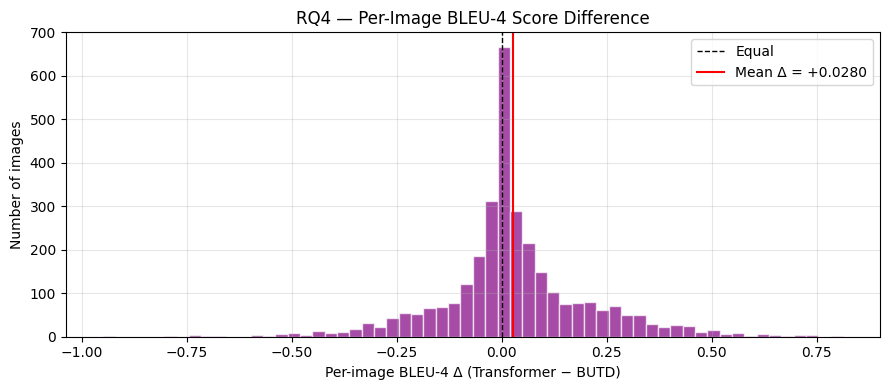

BUTD wins        : 1,328 images (41.8%)
Transformer wins : 1,764 images (55.5%)
Ties             : 86 images


In [ ]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

smooth = SmoothingFunction().method1
per_image = []

for iid in common_ids:
    refs      = [r.lower().split() for r in references[iid]]
    b_hyp     = butd_preds[iid].lower().split()
    t_hyp     = transformer_preds[iid].lower().split()
    b_score   = sentence_bleu(refs, b_hyp, smoothing_function=smooth)
    t_score   = sentence_bleu(refs, t_hyp, smoothing_function=smooth)
    per_image.append((iid, b_score, t_score, t_score - b_score))

per_image.sort(key=lambda x: x[3])
diffs = [x[3] for x in per_image]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(diffs, bins=60, color="purple", alpha=0.7, edgecolor="white")
ax.axvline(0,             color="black", linestyle="--", linewidth=1,   label="Equal")
ax.axvline(np.mean(diffs), color="red",   linestyle="-",  linewidth=1.5,
           label=f"Mean Δ = {np.mean(diffs):+.4f}")
ax.set_xlabel("Per-image BLEU-4 Δ (Transformer − BUTD)")
ax.set_ylabel("Number of images")
ax.set_title("RQ4 — Per-Image BLEU-4 Score Difference")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig("notebooks/rq4_bleu4_diff.png", dpi=120)
plt.show()

butd_wins  = sum(1 for d in diffs if d < 0)
trans_wins = sum(1 for d in diffs if d > 0)
ties       = sum(1 for d in diffs if d == 0)
total      = len(diffs)

print(f"BUTD wins        : {butd_wins:,} images ({100*butd_wins/total:.1f}%)")
print(f"Transformer wins : {trans_wins:,} images ({100*trans_wins/total:.1f}%)")
print(f"Ties             : {ties:,} images")

In [ ]:
print("=" * 70)
print("Images where BUTD is clearly better (Transformer struggles)")
print("=" * 70)
for iid, b, t, diff in per_image[:5]:
    print(f"  {iid}  BUTD={b:.3f}  Trans={t:.3f}  Δ={diff:+.3f}")
    print(f"    BUTD  : {butd_preds[iid]}")
    print(f"    Trans : {transformer_preds[iid]}")
    print()

print("=" * 70)
print("Images where Transformer is clearly better (BUTD struggles)")
print("=" * 70)
for iid, b, t, diff in per_image[-5:][::-1]:
    print(f"  {iid}  BUTD={b:.3f}  Trans={t:.3f}  Δ={diff:+.3f}")
    print(f"    BUTD  : {butd_preds[iid]}")
    print(f"    Trans : {transformer_preds[iid]}")
    print()

Images where BUTD is clearly better (Transformer struggles)
  5621916498.jpg  BUTD=1.000  Trans=0.050  Δ=-0.950
    BUTD  : a little girl is brushing her teeth .
    Trans : a little boy is holding a toothbrush in a bathroom .

  4105945751.jpg  BUTD=0.834  Trans=0.038  Δ=-0.796
    BUTD  : a group of people are standing in front of a building .
    Trans : a man in a black shirt and jeans is holding a piece of paper .

  3248352729.jpg  BUTD=1.000  Trans=0.213  Δ=-0.787
    BUTD  : a snowboarder is jumping over a snowy hill .
    Trans : a person in a red jacket and blue pants is snowboarding down a snowy hill .

  4926719517.jpg  BUTD=0.788  Trans=0.049  Δ=-0.739
    BUTD  : a man and a woman are walking a dog .
    Trans : a woman in a white tank top and black shorts walks a dog on a bicycle .

  3061481868.jpg  BUTD=1.000  Trans=0.267  Δ=-0.733
    BUTD  : two people riding a motorcycle .
    Trans : a man in a black helmet is riding a motorcycle .

Images where Transformer is clea

---
## Final Summary

Consolidated answers to all four research questions.

In [ ]:
print("=" * 70)
print("FINAL RESULTS — BUTD vs Transformer on Flickr30k")
print("=" * 70)

print("\nRQ1 — Caption Quality:")
print(f"  {'Metric':<10} {'BUTD':>8} {'Transformer':>13} {'Winner':>12}")
print("  " + "-" * 46)
for m in metrics:
    b = butd_scores[m]
    t = transformer_scores[m]
    winner = "Transformer" if t > b else ("BUTD" if b > t else "Tie")
    print(f"  {m.upper():<10} {b:>8.4f} {t:>13.4f} {winner:>12}")

if "BUTD" in ckpt_info and "Transformer" in ckpt_info:
    print("\nRQ2 — Convergence:")
    print(f"  BUTD best epoch       : {ckpt_info['BUTD']['best_epoch']} / 20")
    print(f"  Transformer best epoch: {ckpt_info['Transformer']['best_epoch']} / 20")
    print(f"  BUTD val loss         : {ckpt_info['BUTD']['val_loss']:.4f}")
    print(f"  Transformer val loss  : {ckpt_info['Transformer']['val_loss']:.4f}")

print("\nRQ3 — Engineering Practicality:")
print("  Feature extraction  : BUTD ~2-3 hrs GPU  |  Transformer ~2-3 min GPU")
if param_counts:
    print(f"  Decoder parameters  : BUTD {param_counts.get('BUTD', 'N/A'):,}  |  "
          f"Transformer {param_counts.get('Transformer', 'N/A'):,}")

print("\nRQ4 — Qualitative Differences:")
print(f"  BUTD avg caption length        : {np.mean(butd_lengths):.1f} words")
print(f"  Transformer avg caption length : {np.mean(trans_lengths):.1f} words")
print(f"  Human reference avg length     : {np.mean(ref_lengths):.1f} words")
trans_pct = 100 * sum(1 for d in diffs if d > 0) / len(diffs)
print(f"  Transformer wins per-image BLEU-4 on {trans_pct:.1f}% of images")

print("\n" + "=" * 70)

FINAL RESULTS — BUTD vs Transformer on Flickr30k

RQ1 — Caption Quality:
  Metric         BUTD   Transformer       Winner
  ----------------------------------------------
  BLEU_1       0.6318        0.6686  Transformer
  BLEU_2       0.4175        0.4611  Transformer
  BLEU_3       0.2768        0.3183  Transformer
  BLEU_4       0.1854        0.2216  Transformer
  METEOR       0.3920        0.4230  Transformer

RQ2 — Convergence:
  BUTD best epoch       : 16 / 20
  Transformer best epoch: 3 / 20
  BUTD val loss         : 2.5868
  Transformer val loss  : 2.4445

RQ3 — Engineering Practicality:
  Feature extraction  : BUTD ~2-3 hrs GPU  |  Transformer ~2-3 min GPU
  Decoder parameters  : BUTD 18,470,245  |  Transformer 20,851,557

RQ4 — Qualitative Differences:
  BUTD avg caption length        : 12.5 words
  Transformer avg caption length : 12.1 words
  Human reference avg length     : 13.4 words
  Transformer wins per-image BLEU-4 on 55.5% of images



In [ ]:
results = {
    "butd_scores"        : butd_scores,
    "transformer_scores" : transformer_scores,
    "num_eval_images"    : len(common_ids),
    "butd_checkpoint"    : str(BUTD_CHECKPOINT),
    "transformer_checkpoint": str(TRANSFORMER_CHECKPOINT),
}

if "BUTD" in ckpt_info:
    results["butd_best_epoch"]  = ckpt_info["BUTD"]["best_epoch"]
    results["butd_val_loss"]    = ckpt_info["BUTD"]["val_loss"]
if "Transformer" in ckpt_info:
    results["trans_best_epoch"] = ckpt_info["Transformer"]["best_epoch"]
    results["trans_val_loss"]   = ckpt_info["Transformer"]["val_loss"]
if param_counts:
    results["param_counts"] = param_counts

results_path = Path("configs/final_results.json")
with results_path.open("w") as fh:
    json.dump(results, fh, indent=2)
print(f"Results saved to {results_path}")

Results saved to configs/final_results.json
